In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes,add_disinfo_nodes
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing,in_and_out_degree_sum,cross_type_degree
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Scenarie2 = ws_opinion_graph(1000,15,seed = 1)
Scenarie2matrix = create_matrix_rep(Scenarie2)
MedierScenarie2 = add_media_nodes(Scenarie2matrix,100, seed =11, factor = 1)
DisinfoScenarie2 = add_disinfo_nodes(MedierScenarie2,100,seed = 11)

In [3]:
DisinfoScenarie2.opinions, Scenarie2_sim_results,Scenarie2_startcond,Scenarie2_endcond= simpel_simulering(DisinfoScenarie2,200)

Simulating: 100%|██████████| 200/200 [00:00<00:00, 462.65it/s]


In [4]:
Hoved_average_opinionresult, Hoved_average_distance_to_the_mean_result = data_processing(Scenarie2_sim_results,maskhumanScenarie2)
maskhumanScenarie2 = DisinfoScenarie2.type == "Human"


NameError: name 'maskhumanScenarie2' is not defined

In [ ]:
binsScenarie2 = np.histogram_bin_edges(np.concatenate([Scenarie2_startcond[maskhumanScenarie2], Scenarie2_endcond[maskhumanScenarie2]]), bins=100)


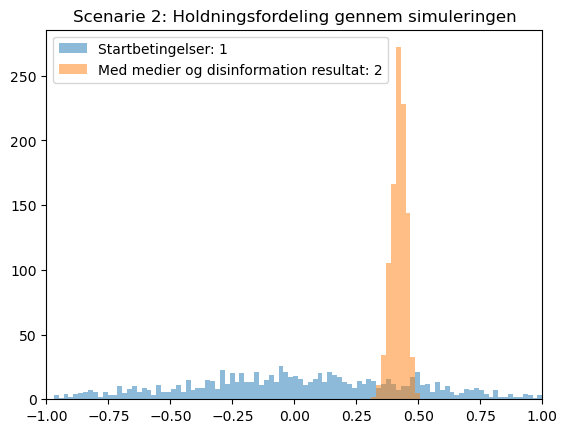

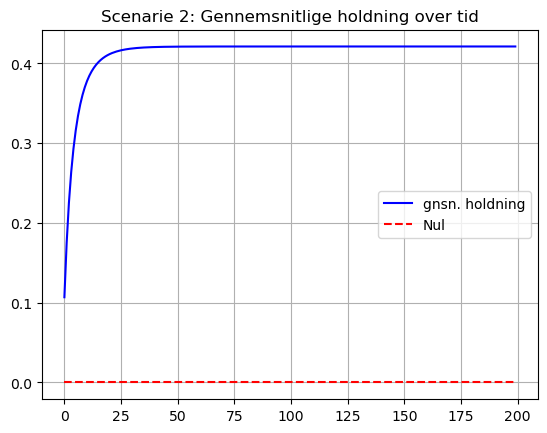

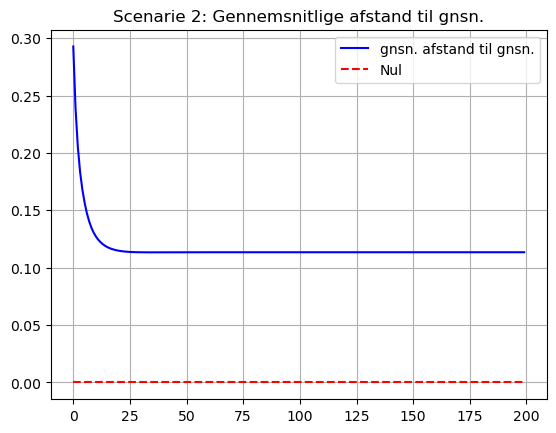

In [ ]:
plt.figure()
plt.hist(Scenarie2_startcond[maskhumanScenarie2], bins=binsScenarie2, alpha=0.5, label='Startbetingelser: 1')
plt.hist(Scenarie2_endcond[maskhumanScenarie2], bins=binsScenarie2, alpha=0.5, label='Med medier og disinformation resultat: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 2: Holdningsfordeling gennem simuleringen')
plt.show()


plt.figure()
plt.plot(np.arange(len(Hoved_average_opinionresult)),Hoved_average_opinionresult,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(Hoved_average_opinionresult)),np.zeros(len(Hoved_average_opinionresult)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 2: Gennemsnitlige holdning over tid')
plt.show()

plt.figure()
plt.plot(np.arange(len(Hoved_average_distance_to_the_mean_result)),Hoved_average_distance_to_the_mean_result,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(Hoved_average_distance_to_the_mean_result)),np.zeros(len(Hoved_average_distance_to_the_mean_result)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 2: Gennemsnitlige afstand til gnsn.')
plt.show()

In [ ]:
indout = ws_opinion_graph(10,4,seed = 200)
indoutmatrix = create_matrix_rep(indout)


In [ ]:
ind , out  = in_and_out_degree_sum(DisinfoScenarie2)

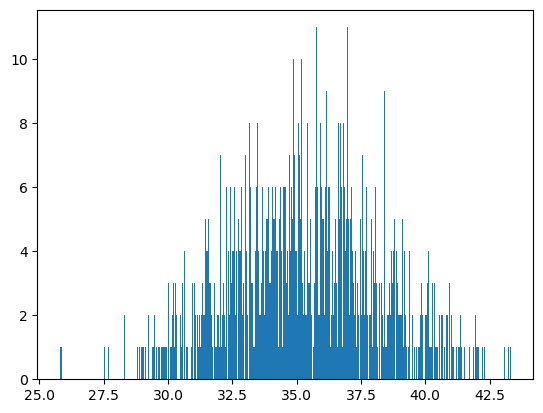

In [ ]:
plt.figure()
plt.hist(ind[maskhumanScenarie2],bins = 500)
plt.show()

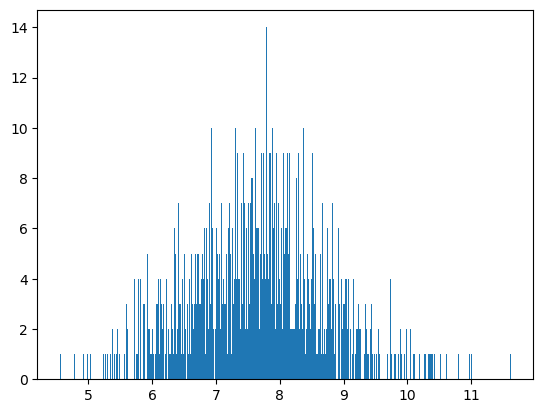

In [ ]:
plt.figure()
plt.hist(out[maskhumanScenarie2],bins= 500)
plt.show()

In [ ]:
print(max(out))
print(min(out))


501.11
1.9800000000000002


In [ ]:
print(out.mean())

29.424266666666668


In [ ]:
received, sent = cross_type_degree(DisinfoScenarie2, source_type='Media', target_type='Human')


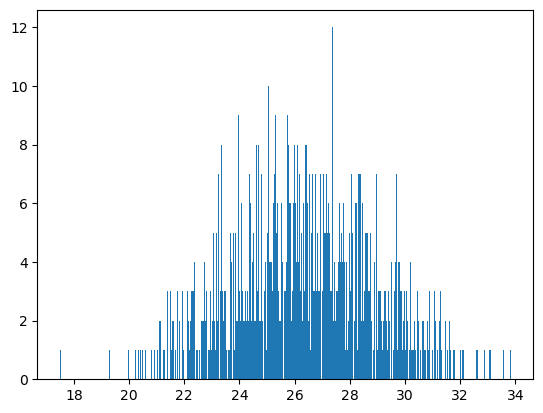

In [ ]:
plt.figure()
plt.hist(received,bins = 500)
plt.show()

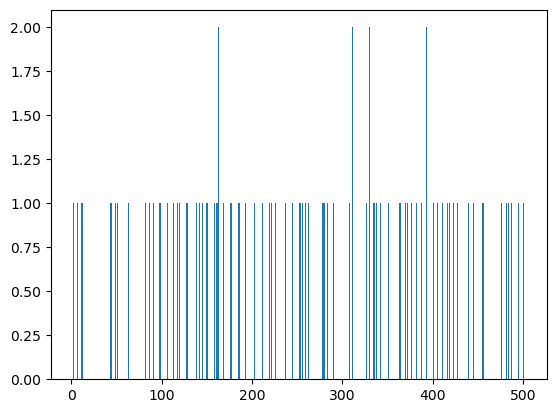

In [ ]:
plt.figure()
plt.hist(sent,bins= 500)
plt.show()